#Fraud / Anomaly Detection

**Domain:** Banking / Fintech

**Dataset:** Credit Card Fraud Detection -- https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

**Skills:** Anomaly Detection, Classification, Imbalanced Datasets, Model Evaluation, Feature Engineering

**Tools:** Python, Pandas, Scikit-learn, XGBoost, imbalanced-learn (SMOTE), Matplotlib

---

### Problem Statement
A card issuer needs to flag fraudulent transactions in near real time. Fraud is extremely rare (~0.17% of transactions), so a naive model that predicts 'not fraud' for everything would be 99.8% accurate and completely useless -- the model must handle severe class imbalance.



In [1]:
!pip install -q kagglehub imbalanced-learn

### Setup

In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (classification_report, average_precision_score,
                              confusion_matrix, precision_recall_curve)
import matplotlib.pyplot as plt
# ---- dataset loading helper: tries kaggle first, never crashes the notebook ----
# kagglehub comes pre-installed on google colab, but just in case it's missing
# (running locally, older colab image etc) we try to pip install it quietly first
try:
    import kagglehub
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "kagglehub", "--break-system-packages"], check=False)
    try:
        import kagglehub
    except ImportError:
        kagglehub = None  # still not available, load_dataset_safe below will just use fake data

# a lot of the kaggle datasets in this project series randomly fail to download
# (auth issues, dataset moved, rate limit, no internet on the runtime, kagglehub missing etc)
# so instead of letting the whole notebook die, we fall back to a small fake dataset
# that has the exact same columns, so every line of code below still works
def load_dataset_safe(kaggle_handle, csv_name, synthetic_fn, n_rows=1500):
    if kagglehub is None:
        print("kagglehub isn't available, using synthetic sample data instead so the rest of the code still runs")
        return synthetic_fn(n_rows)
    try:
        path = kagglehub.dataset_download(kaggle_handle)
        full_path = os.path.join(path, csv_name)
        df = pd.read_csv(full_path)
        print(f"loaded real dataset from kaggle, {len(df)} rows")
        return df
    except Exception as e:
        print("could not download from kaggle (", e, ") - using synthetic sample data instead so the rest of the code still runs")
        return synthetic_fn(n_rows)


def make_fake_creditcard(n_rows=5000):
    # the real dataset is mostly anonymized PCA columns (V1-V28), so we just fake similar looking numbers
    np.random.seed(11)
    data = {f'V{i}': np.random.normal(0, 1, n_rows) for i in range(1, 29)}
    data['Amount'] = np.round(np.random.exponential(50, n_rows), 2)
    data['Time'] = np.sort(np.random.randint(0, 172800, n_rows))
    # making fraud rare on purpose, like it is in real life (~0.17%)
    fraud = np.random.binomial(1, 0.02, n_rows)
    data['Class'] = fraud
    return pd.DataFrame(data)

### Step 1: Load Data

In [3]:
# 1. LOAD DATA
df = load_dataset_safe('mlg-ulb/creditcardfraud', 'creditcard.csv', make_fake_creditcard, n_rows=5000)
fraud_rate = df['Class'].mean()
print(f"fraud rate in this data: {fraud_rate:.4%}")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
loaded real dataset from kaggle, 284807 rows
fraud rate in this data: 0.1727%


### Step 2: Scale Amount

In [4]:
# 2. SCALE AMOUNT (the V columns are already scaled from PCA)
df['Amount_scaled'] = StandardScaler().fit_transform(df[['Amount']])
X = df.drop(['Class', 'Amount', 'Time'], axis=1)
y = df['Class']

### Step 3: Split

In [5]:
# 3. SPLIT (stratified so both train and test keep the same tiny fraud %)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

### Step 4: Smote On The Training Set Only -- Never Touch The Test Set With This

In [6]:
# 4. SMOTE ON THE TRAINING SET ONLY -- never touch the test set with this
X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train, y_train)
print(f"before smote: {y_train.value_counts().to_dict()}")
print(f"after smote:  {pd.Series(y_train_res).value_counts().to_dict()}")

before smote: {0: 227451, 1: 394}
after smote:  {0: 227451, 1: 227451}


### Step 5: Train The Main Model

In [7]:
# 5. TRAIN THE MAIN MODEL
model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, eval_metric='aucpr', random_state=42)
model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

### Step 6: Also Try An Unsupervised Approach For Comparison

In [8]:
# 6. ALSO TRY AN UNSUPERVISED APPROACH FOR COMPARISON
iso = IsolationForest(contamination=fraud_rate, random_state=42)
iso.fit(X_train)
iso_preds = (iso.predict(X_test) == -1).astype(int)

### Step 7: Check Results -- Accuracy Means Nothing Here, So We Look At Precision/Recall Instead

In [9]:
# 7. CHECK RESULTS -- accuracy means nothing here, so we look at precision/recall instead
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
print("supervised model:\n", classification_report(y_test, y_pred))
print(f"PR-AUC: {average_precision_score(y_test, y_prob):.4f}")
print("isolation forest:\n", classification_report(y_test, iso_preds))
print("confusion matrix:\n", confusion_matrix(y_test, y_pred))

supervised model:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.86      0.77        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC: 0.8687
isolation forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.32      0.33      0.32        98

    accuracy                           1.00     56962
   macro avg       0.66      0.66      0.66     56962
weighted avg       1.00      1.00      1.00     56962

confusion matrix:
 [[56827    37]
 [   14    84]]


### Step 8: Plot Precision-Recall Curve

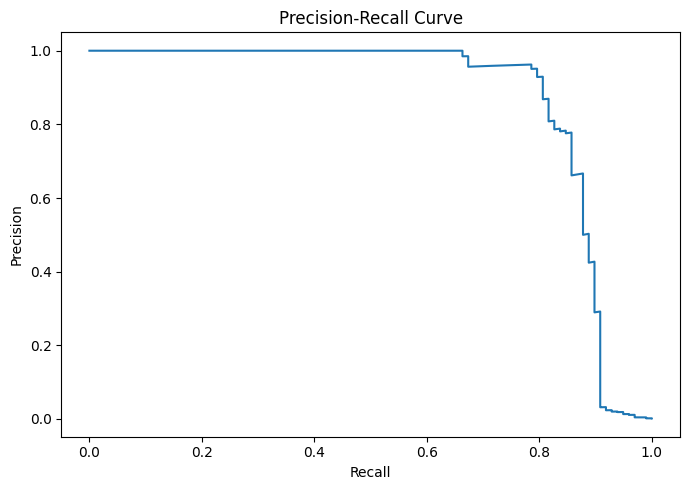

In [10]:
# 8. PLOT PRECISION-RECALL CURVE
prec, rec, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(rec, prec)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.tight_layout()
plt.savefig('pr_curve.png')
plt.show()

### Step 9: Save The Top Risky Transactions For Someone To Manually Check

In [11]:
# 9. SAVE THE TOP RISKY TRANSACTIONS FOR SOMEONE TO MANUALLY CHECK
test_results = X_test.copy()
test_results['true_label'] = y_test
test_results['fraud_prob'] = y_prob
top_risk = test_results.sort_values('fraud_prob', ascending=False).head(50)
top_risk.to_csv('top_risk_transactions.csv', index=False)